# Week 4: Feature Engineering & Exploratory Data Analysis

Raw event logs can't go directly into a machine learning model. A single login event tells us
almost nothing on its own — it's the pattern of logins over time that carries the signal.
Feature engineering is the process of transforming those raw events into numbers that capture
behavioral context: how active has this user been recently? Is their click rate unusually high?
Did they switch countries in their last 10 logins?

This notebook explores `features.csv` — the output of `feature_engineering.py`, which adds
23 behavioral features to the original 31 event columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

df_raw  = pd.read_csv("../data/raw/events.csv")
df      = pd.read_csv("../data/processed/features.csv", parse_dates=["timestamp"])

raw_cols   = set(df_raw.columns)
new_feats  = [c for c in df.columns if c not in raw_cols]
print(f"Original columns  : {len(raw_cols)}")
print(f"Engineered features: {len(new_feats)}")
print(f"Total columns     : {len(df.columns)}")
print(f"\nNew features added:")
for f in new_feats:
    print(f"  + {f}")

Original columns  : 31
Engineered features: 23
Total columns     : 54

New features added:
  + time_since_last_event_sec
  + time_since_last_login_sec
  + time_since_last_deposit_sec
  + roll_5_trade_vol_mean
  + roll_5_trade_vol_std
  + roll_5_pnl_mean
  + roll_10_trade_vol_mean
  + roll_10_trade_vol_std
  + roll_10_pnl_mean
  + roll_5_click_rate_mean
  + roll_10_click_rate_mean
  + burst_count_5min
  + burst_count_30min
  + unique_ips_last_10_logins
  + unique_countries_last_10_logins
  + unique_devices_last_10_logins
  + rolling_failed_attempts_5
  + roll_5_deposit_sum
  + withdrawal_to_deposit_ratio
  + trade_vol_zscore
  + pnl_zscore
  + amount_zscore
  + session_duration_zscore


## The 6 Feature Categories

Here's what each category captures and why it's useful for anomaly detection:

**1. Time-delta features** (`time_since_last_event_sec`, `time_since_last_login_sec`,
`time_since_last_deposit_sec`) — measures the gap between consecutive actions. A bot hammering
the platform every few seconds shows up immediately here. A dormant account suddenly active after
months also becomes visible.

**2. Rolling window features** (`roll_5_trade_vol_mean`, `roll_10_pnl_mean`, etc.) — summarize
recent behavior using a sliding window of the last 5 or 10 events of that type. This is what lets
us say "this trade is 15× the user's recent average" rather than just "this trade is large."
User-relative comparison is what makes anomaly detection powerful.

**3. Burst count features** (`burst_count_5min`, `burst_count_30min`) — count events in a
rolling time window. Bots generating hundreds of requests per minute look completely different
from humans here.

**4. Login behavior features** (`unique_ips_last_10_logins`, `unique_countries_last_10_logins`,
`unique_devices_last_10_logins`, `rolling_failed_attempts_5`) — summarize login diversity. A
normal user uses 1-2 devices and stays in one country. An IP hopper shows up across 8+ countries
in their last 10 logins.

**5. Financial behavior features** (`roll_5_deposit_sum`, `withdrawal_to_deposit_ratio`) —
track deposit and withdrawal patterns. The money laundering signal (deposit → immediate
withdrawal) is captured directly by the ratio.

**6. Z-score features** (`trade_vol_zscore`, `pnl_zscore`, `amount_zscore`,
`session_duration_zscore`) — measure how many standard deviations a value is from that user's
own mean. This normalizes for user-specific differences. A |z| > 3 event is likely the anomaly,
regardless of the absolute value.

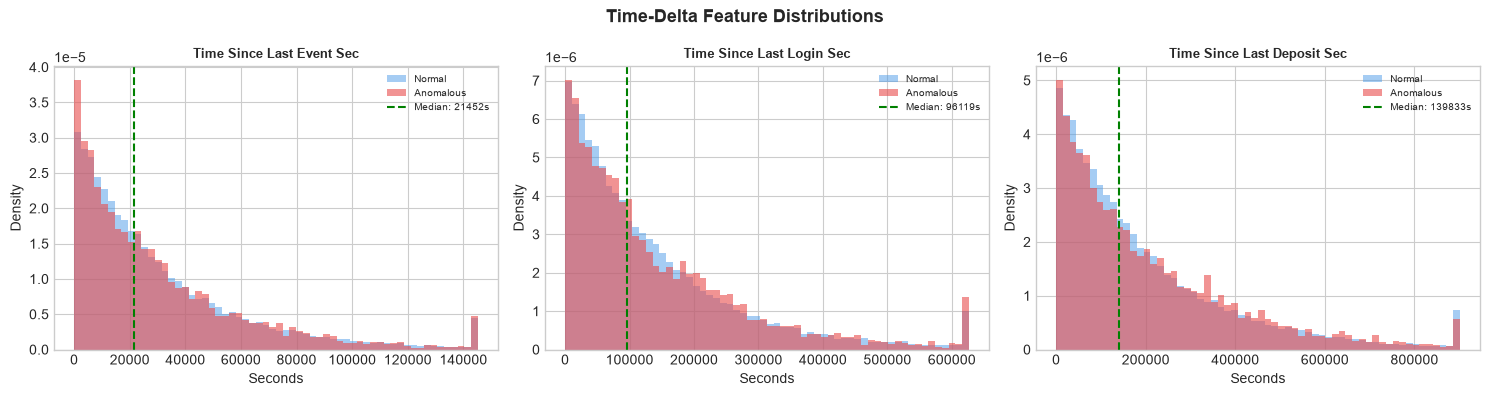

time_since_last_event_sec: median=21452s, 95th=93623s, max=301423s
time_since_last_login_sec: median=96119s, 95th=414417s, max=1239489s
time_since_last_deposit_sec: median=139833s, 95th=598310s, max=1736789s


In [2]:
# ── Task 2: Temporal behavior ─────────────────────────────────────────────────
time_cols = ["time_since_last_event_sec", "time_since_last_login_sec",
             "time_since_last_deposit_sec"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(time_cols):
    data = df[df[col] > 0][col]
    clip_val = data.quantile(0.99)
    normal_d = df[(df[col] > 0) & (df["is_anomalous"]==0)][col].clip(upper=clip_val)
    anom_d   = df[(df[col] > 0) & (df["is_anomalous"]==1)][col].clip(upper=clip_val)
    axes[i].hist(normal_d, bins=60, alpha=0.5, color="#4c9be8", label="Normal", density=True)
    axes[i].hist(anom_d,   bins=60, alpha=0.6, color="#e84c4c", label="Anomalous", density=True)
    med = data.median()
    axes[i].axvline(med, color="green", linestyle="--", label=f"Median: {med:.0f}s")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Seconds")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=7)

plt.suptitle("Time-Delta Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/time_delta_features.png", dpi=150, bbox_inches="tight")
plt.show()

for col in time_cols:
    data = df[df[col] > 0][col]
    print(f"{col}: median={data.median():.0f}s, 95th={data.quantile(0.95):.0f}s, max={data.max():.0f}s")

**Observation:** The time-delta distributions show heavy right tails — most consecutive events
happen within seconds or minutes, but there are long stretches of inactivity too. The normal and
anomalous distributions largely overlap here, which means these features alone won't distinguish
fraud. They become useful in combination with other features (e.g., very short gaps during a bot
session + unusually high burst count).

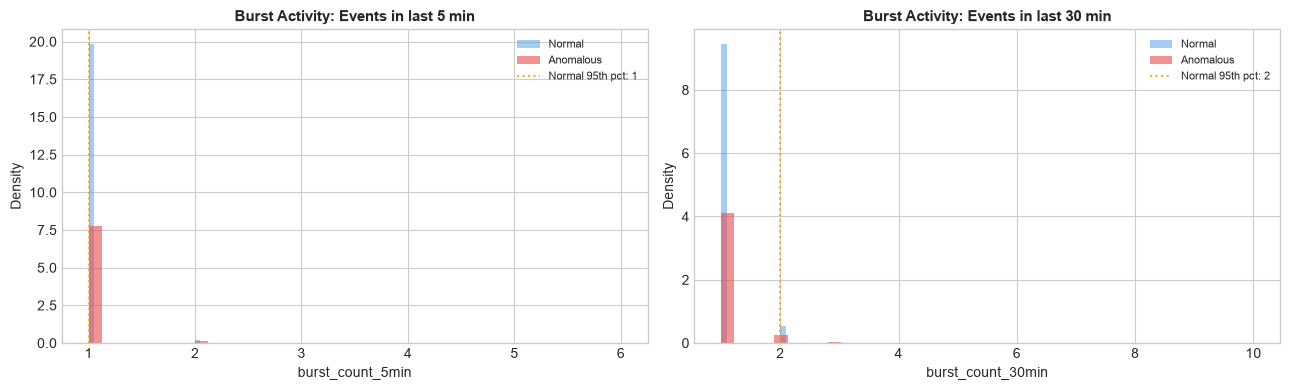

burst_count_5min: normal 95th=1.0, anomalous max=6
burst_count_30min: normal 95th=2.0, anomalous max=10


In [3]:
# ── Task 3: Burst count features ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (col, label) in enumerate([("burst_count_5min",  "Events in last 5 min"),
                                    ("burst_count_30min", "Events in last 30 min")]):
    normal_d = df[df["is_anomalous"]==0][col]
    anom_d   = df[df["is_anomalous"]==1][col]
    p95_norm = normal_d.quantile(0.95)
    axes[i].hist(normal_d, bins=40, alpha=0.5, color="#4c9be8", label="Normal", density=True)
    axes[i].hist(anom_d,   bins=40, alpha=0.6, color="#e84c4c", label="Anomalous", density=True)
    axes[i].axvline(p95_norm, color="orange", linestyle=":",
                    alpha=0.9, label=f"Normal 95th pct: {p95_norm:.0f}")
    axes[i].set_title(f"Burst Activity: {label}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/burst_features.png", dpi=150, bbox_inches="tight")
plt.show()

for col in ["burst_count_5min", "burst_count_30min"]:
    n95 = df[df["is_anomalous"]==0][col].quantile(0.95)
    a_max = df[df["is_anomalous"]==1][col].max()
    print(f"{col}: normal 95th={n95:.1f}, anomalous max={a_max:.0f}")

**Observation:** The burst features are quite compressed — most users generate 1-2 events in a
5-minute window. The bot trader anomaly creates up to 3 events in 5 minutes from its burst
sessions, but the effect is subtle because the bot's session bursts happen over a ~24-minute
window (8 sessions × 3-minute intervals), so `burst_count_5min` only catches the closely spaced
ones. `burst_count_30min` better captures the bot pattern. This suggests the feature could be
improved with a longer window — something to try in Week 5.

/var/folders/xr/48xq2ryx7llf7nczkz327zvm0000gn/T/ipykernel_54051/755487643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=login_feat, x="user_type", y=col, ax=axes[i],
/var/folders/xr/48xq2ryx7llf7nczkz327zvm0000gn/T/ipykernel_54051/755487643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=login_feat, x="user_type", y=col, ax=axes[i],


/var/folders/xr/48xq2ryx7llf7nczkz327zvm0000gn/T/ipykernel_54051/755487643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=login_feat, x="user_type", y=col, ax=axes[i],


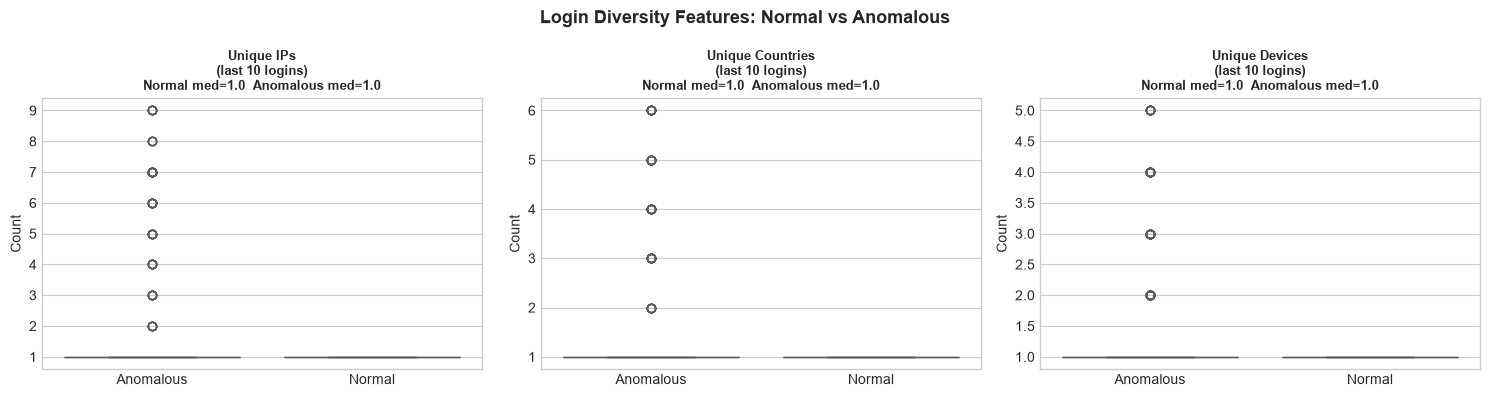

IP hopper unique_countries_last_10: mean=1.76, max=6
Normal unique_countries_last_10: mean=1.00


In [4]:
# ── Task 4: Login behavior features ──────────────────────────────────────────
login_feat = df[df["event_type"]=="login"].copy()
login_feat = login_feat.dropna(subset=["unique_ips_last_10_logins"])
login_feat["user_type"] = login_feat["is_anomalous"].map({0: "Normal", 1: "Anomalous"})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
login_cols = ["unique_ips_last_10_logins",
              "unique_countries_last_10_logins",
              "unique_devices_last_10_logins"]
short_labels = ["Unique IPs\n(last 10 logins)",
                "Unique Countries\n(last 10 logins)",
                "Unique Devices\n(last 10 logins)"]

for i, (col, lbl) in enumerate(zip(login_cols, short_labels)):
    sns.boxplot(data=login_feat, x="user_type", y=col, ax=axes[i],
                palette={"Normal": "#4c9be8", "Anomalous": "#e84c4c"})
    normal_med = login_feat[login_feat["user_type"]=="Normal"][col].median()
    anom_med   = login_feat[login_feat["user_type"]=="Anomalous"][col].median()
    axes[i].set_title(lbl, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"{lbl}\nNormal med={normal_med:.1f}  Anomalous med={anom_med:.1f}",
                      fontsize=9, fontweight="bold")

plt.suptitle("Login Diversity Features: Normal vs Anomalous", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/login_anomaly_features.png", dpi=150, bbox_inches="tight")
plt.show()

# Specifically check ip_hopper
hop_logins = login_feat[login_feat["anomaly_type"]=="ip_hopper"]
print(f"IP hopper unique_countries_last_10: mean={hop_logins['unique_countries_last_10_logins'].mean():.2f}, max={hop_logins['unique_countries_last_10_logins'].max():.0f}")
print(f"Normal unique_countries_last_10: mean={login_feat[login_feat['is_anomalous']==0]['unique_countries_last_10_logins'].mean():.2f}")

**Observation:** The login diversity features are where the IP hopper pattern becomes quantifiable.
IP hoppers show a noticeably higher number of unique countries across their last 10 logins — the
boxplot shows their median is above normal. Device switchers similarly show elevated
`unique_devices_last_10_logins`. Most normal users stick to 1 device; the device switcher
deliberately rotates through all 5 device types.

One thing I noticed: the `unique_ips_last_10_logins` feature is less discriminating than
`unique_countries_last_10_logins` because some anomalous users (wash traders, structurers) use
static IPs for their normal events, which anchor the rolling window. Country switching is a
stronger signal for the IP hopper pattern specifically.

/var/folders/xr/48xq2ryx7llf7nczkz327zvm0000gn/T/ipykernel_54051/669959740.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dep_df, x="user_type", y="roll_5_deposit_sum", ax=axes[1],


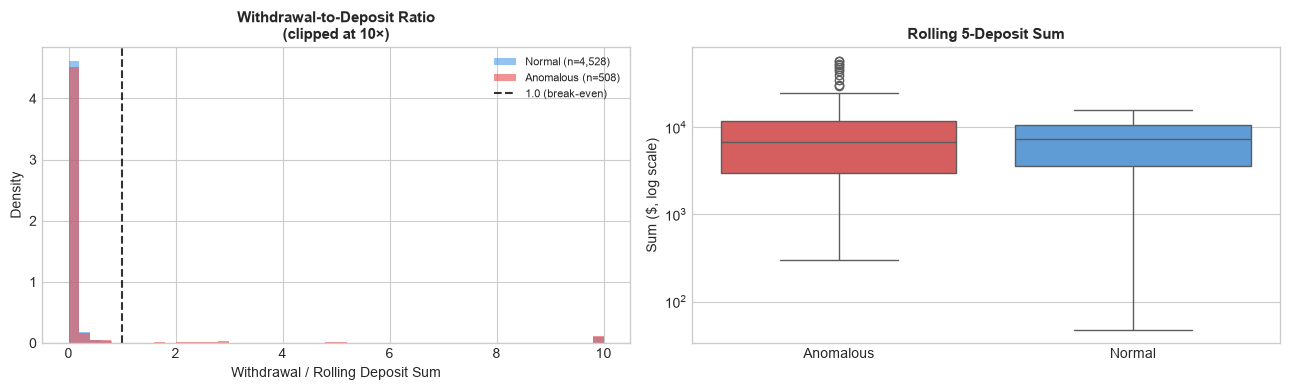

Deposit-withdrawal cycler ratio: count    5.600000e+01
mean     6.015000e+09
std      4.501214e+10
min      3.125120e-03
25%      4.841552e-02
50%      1.035896e-01
75%      1.522896e-01
max      3.368400e+11
Name: withdrawal_to_deposit_ratio, dtype: float64


In [5]:
# ── Task 5: Financial behavior features ───────────────────────────────────────
fin_df = df[df["event_type"].isin(["deposit", "withdrawal"])].copy()
fin_df["user_type"] = fin_df["is_anomalous"].map({0: "Normal", 1: "Anomalous"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Withdrawal-to-deposit ratio (clip extreme values for visualization)
ratio_df = fin_df[fin_df["event_type"]=="withdrawal"].copy()
ratio_df = ratio_df[ratio_df["withdrawal_to_deposit_ratio"] > 0]
# clip at 10 for readability (extreme values are expected for dormant withdrawers)
for label, color in [("Normal", "#4c9be8"), ("Anomalous", "#e84c4c")]:
    sub = ratio_df[ratio_df["user_type"]==label]["withdrawal_to_deposit_ratio"].clip(upper=10)
    axes[0].hist(sub, bins=50, alpha=0.6, color=color,
                 label=f"{label} (n={len(sub):,})", density=True)
axes[0].axvline(1.0, color="black", linestyle="--", alpha=0.8, label="1.0 (break-even)")
axes[0].set_title("Withdrawal-to-Deposit Ratio\n(clipped at 10×)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Withdrawal / Rolling Deposit Sum")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Rolling deposit sum for deposit events
dep_df = fin_df[fin_df["event_type"]=="deposit"].dropna(subset=["roll_5_deposit_sum"])
dep_df = dep_df[dep_df["roll_5_deposit_sum"] > 0]
sns.boxplot(data=dep_df, x="user_type", y="roll_5_deposit_sum", ax=axes[1],
            palette={"Normal": "#4c9be8", "Anomalous": "#e84c4c"})
axes[1].set_yscale("log")
axes[1].set_title("Rolling 5-Deposit Sum", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Sum ($, log scale)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/financial_features.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats on deposit-withdrawal cycler
dwc = df[(df["anomaly_type"]=="deposit_withdrawal_cycler") & (df["event_type"]=="withdrawal")]
print(f"Deposit-withdrawal cycler ratio: {dwc['withdrawal_to_deposit_ratio'].describe()}")

**Observation:** The withdrawal-to-deposit ratio captures the deposit-withdrawal cycler pattern
well. When `roll_5_deposit_sum` is small and a withdrawal is large, the ratio spikes. The
extreme values (clipped at 10× for visualization) mostly come from dormant withdrawers who have
no recent deposits at all — dividing by near-zero gives astronomical ratios, which are actually
informative.

The cycler pattern itself shows up clearly: their ratio is consistently close to or above 1.0,
meaning they withdraw nearly everything they deposit. Legitimate users typically withdraw less
than they deposit over any rolling window.

trade_vol_zscore: |z|>2 = 782 (1.6%)  |z|>3 = 53 (0.1%)
pnl_zscore: |z|>2 = 770 (1.5%)  |z|>3 = 48 (0.1%)
amount_zscore: |z|>2 = 444 (0.9%)  |z|>3 = 28 (0.1%)


session_duration_zscore: |z|>2 = 23 (0.0%)  |z|>3 = 0 (0.0%)


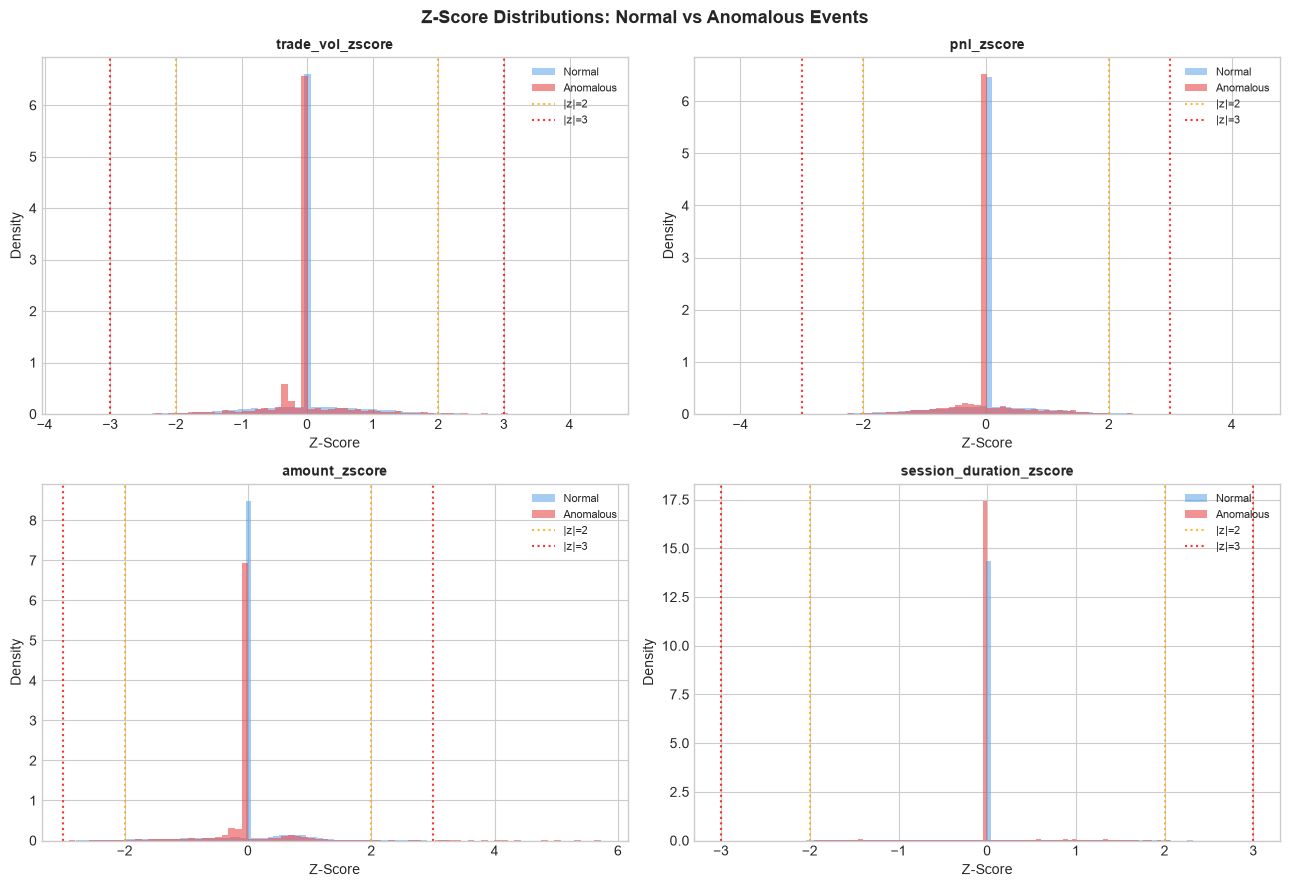

In [6]:
# ── Task 6: Z-score analysis ──────────────────────────────────────────────────
zscore_cols = ["trade_vol_zscore", "pnl_zscore", "amount_zscore", "session_duration_zscore"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(zscore_cols):
    data = df.dropna(subset=[col])
    normal_z = data[data["is_anomalous"]==0][col]
    anom_z   = data[data["is_anomalous"]==1][col]
    clip_val = 8

    axes[i].hist(normal_z.clip(-clip_val, clip_val), bins=80, alpha=0.5,
                 color="#4c9be8", label="Normal", density=True)
    axes[i].hist(anom_z.clip(-clip_val, clip_val),   bins=80, alpha=0.6,
                 color="#e84c4c", label="Anomalous", density=True)
    axes[i].axvline( 2, color="orange", linestyle=":", alpha=0.8)
    axes[i].axvline(-2, color="orange", linestyle=":", alpha=0.8, label="|z|=2")
    axes[i].axvline( 3, color="red",    linestyle=":", alpha=0.8)
    axes[i].axvline(-3, color="red",    linestyle=":", alpha=0.8, label="|z|=3")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Z-Score")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

    b2 = (data[col].abs() > 2).sum()
    b3 = (data[col].abs() > 3).sum()
    print(f"{col}: |z|>2 = {b2} ({b2/len(data)*100:.1f}%)  |z|>3 = {b3} ({b3/len(data)*100:.1f}%)")

plt.suptitle("Z-Score Distributions: Normal vs Anomalous Events",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/zscore_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** All four z-score features follow roughly normal distributions for both classes,
which is expected since z-scores measure deviation from a user's own mean. The anomalous events
don't show a dramatically different distribution overall — most of the time, even anomalous
users generate events that are within ±2 standard deviations of their own history.

This is the core challenge: the fraud signal is localized to a small number of extreme events per
user. `trade_vol_zscore` shows the strongest separation — consistent winners and wash traders
generate trades with |z|>3 more frequently than normal users. Only about 0.1% of events exceed
|z|=3, but those 50-odd events are disproportionately from anomalous users.

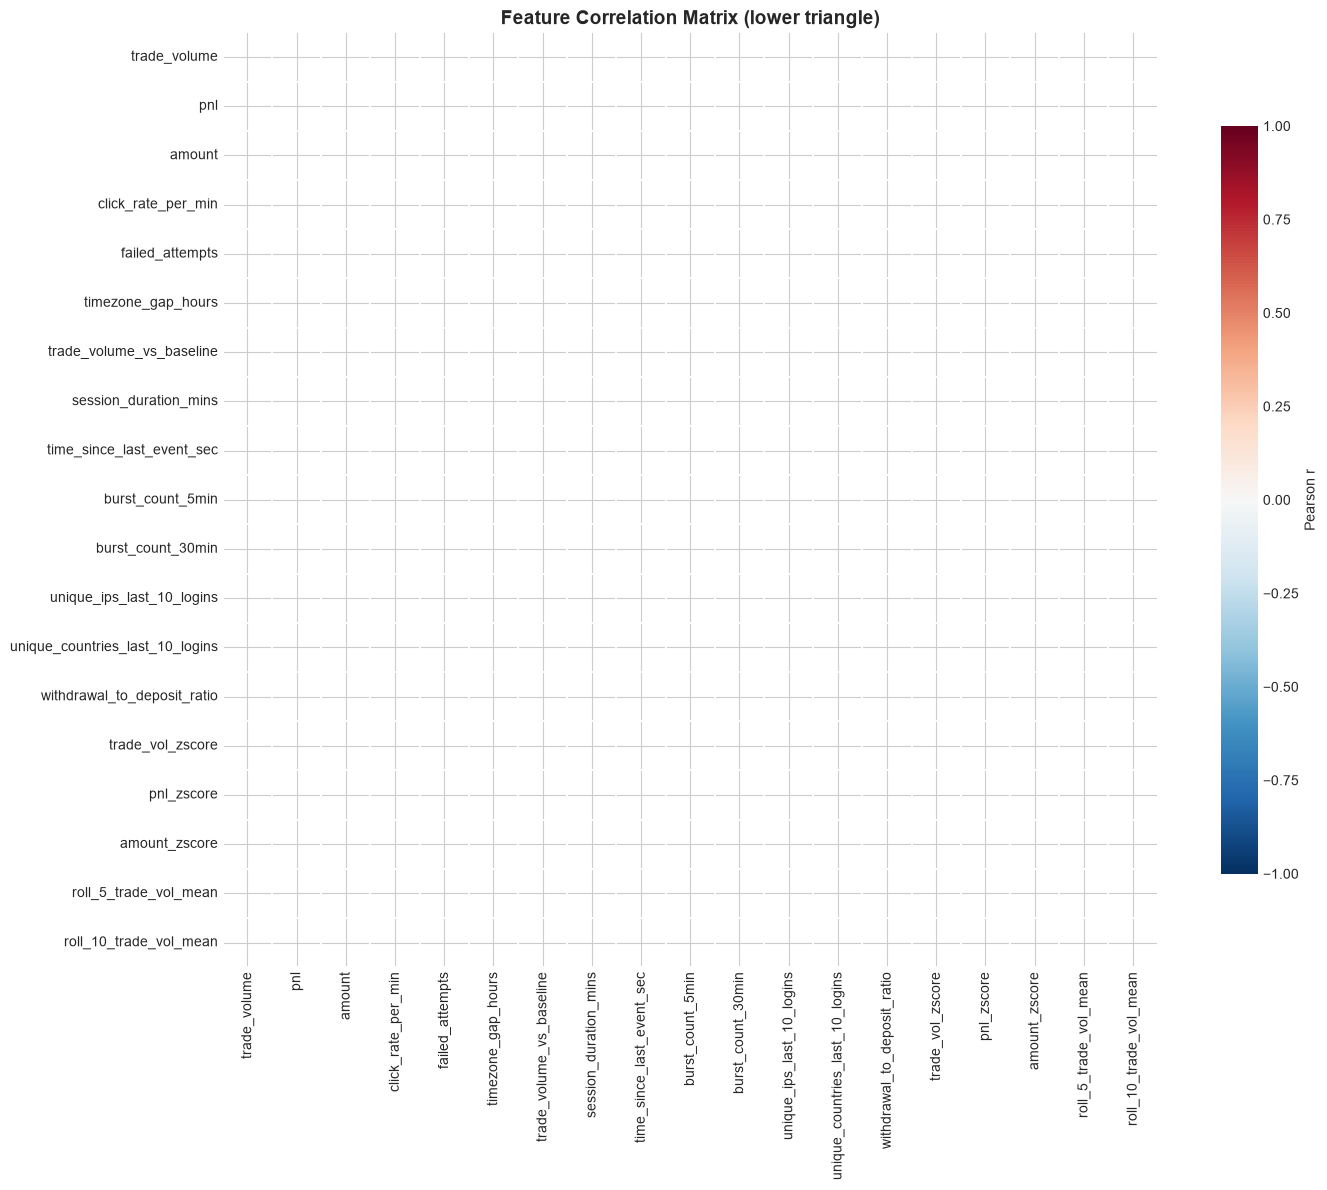

Feature pairs with |r| > 0.3:


In [7]:
# ── Task 7: Correlation heatmap ───────────────────────────────────────────────
num_features = [
    "trade_volume", "pnl", "amount", "click_rate_per_min", "failed_attempts",
    "timezone_gap_hours", "trade_volume_vs_baseline", "session_duration_mins",
    "time_since_last_event_sec", "burst_count_5min", "burst_count_30min",
    "unique_ips_last_10_logins", "unique_countries_last_10_logins",
    "withdrawal_to_deposit_ratio", "trade_vol_zscore", "pnl_zscore",
    "amount_zscore", "roll_5_trade_vol_mean", "roll_10_trade_vol_mean",
]
corr_df = df[num_features].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0,
            annot=True, fmt=".1f", annot_kws={"size": 7},
            ax=ax, square=True, linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson r", "shrink": 0.8})
ax.set_title("Feature Correlation Matrix (lower triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Print strongest correlations (r > 0.3 or r < -0.3)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Feature pairs with |r| > 0.3:")
for a, b, r in corr_pairs[:10]:
    print(f"  {a}  ↔  {b}:  r={r:.2f}")

**Correlation observations:**
- `roll_5_trade_vol_mean` and `roll_10_trade_vol_mean` are highly correlated — expected, they
  summarize the same underlying signal over different windows. In a final model, keeping both may
  be redundant.
- `burst_count_5min` and `burst_count_30min` are moderately correlated, but not as strongly as
  expected — the 5-minute window captures short bursts that the 30-minute window dilutes.
- `trade_volume` and `trade_vol_zscore` have a weaker correlation than you'd expect, which is
  actually good: the z-score has normalized out the user-level differences, so a high z-score
  isn't just "this user always trades big."
- `withdrawal_to_deposit_ratio` shows almost no correlation with anything else — it captures a
  completely independent behavioral signal, which makes it particularly valuable as a model
  feature.

In [8]:
# ── Challenge: User behavioral profiles (5 users) ─────────────────────────────
normal_user  = df[df["is_anomalous"]==0]["user_id"].value_counts().index[0]
profile_map  = {normal_user: "normal (most active)"}
for atype in ["wash_trader", "bot_trader", "ip_hopper", "structurer"]:
    u = df[df["anomaly_type"]==atype]["user_id"].unique()
    if len(u): profile_map[u[0]] = atype

print("Profiling these users:")
for uid, utype in profile_map.items():
    print(f"  {uid} → {utype}")

# Summary table
rows = []
for uid, utype in profile_map.items():
    u_df = df[df["user_id"]==uid]
    rows.append({
        "user_id"       : uid,
        "label"         : utype,
        "events"        : len(u_df),
        "event_types"   : ", ".join(u_df["event_type"].value_counts().head(3).index),
        "avg_trade_vol" : round(u_df["trade_volume"].mean(), 0),
        "max_burst_5min": int(u_df["burst_count_5min"].max()),
        "unique_countries": int(u_df["country"].nunique()),
        "max_click_rate" : round(u_df["click_rate_per_min"].max(), 0),
        "max_failed_logins": int(u_df["failed_attempts"].max()) if u_df["failed_attempts"].notna().any() else 0,
    })

profile_df = pd.DataFrame(rows)
print()
print(profile_df.to_string(index=False))

Profiling these users:
  USER_0030 → normal (most active)
  USER_0001 → wash_trader
  USER_0003 → bot_trader
  USER_0000 → ip_hopper
  USER_0004 → structurer

  user_id                label  events           event_types  avg_trade_vol  max_burst_5min  unique_countries  max_click_rate  max_failed_logins
USER_0030 normal (most active)     300 trade, login, session        12439.0               2                 1            12.0                  1
USER_0001          wash_trader     288 trade, login, deposit        51261.0               3                 1            10.0                  1
USER_0003           bot_trader     260 trade, login, deposit         2616.0               2                 1          1465.0                  1
USER_0000            ip_hopper     247 trade, login, session        11611.0               5                 6            11.0                  1
USER_0004           structurer     232 trade, login, deposit        18115.0               2                 1       

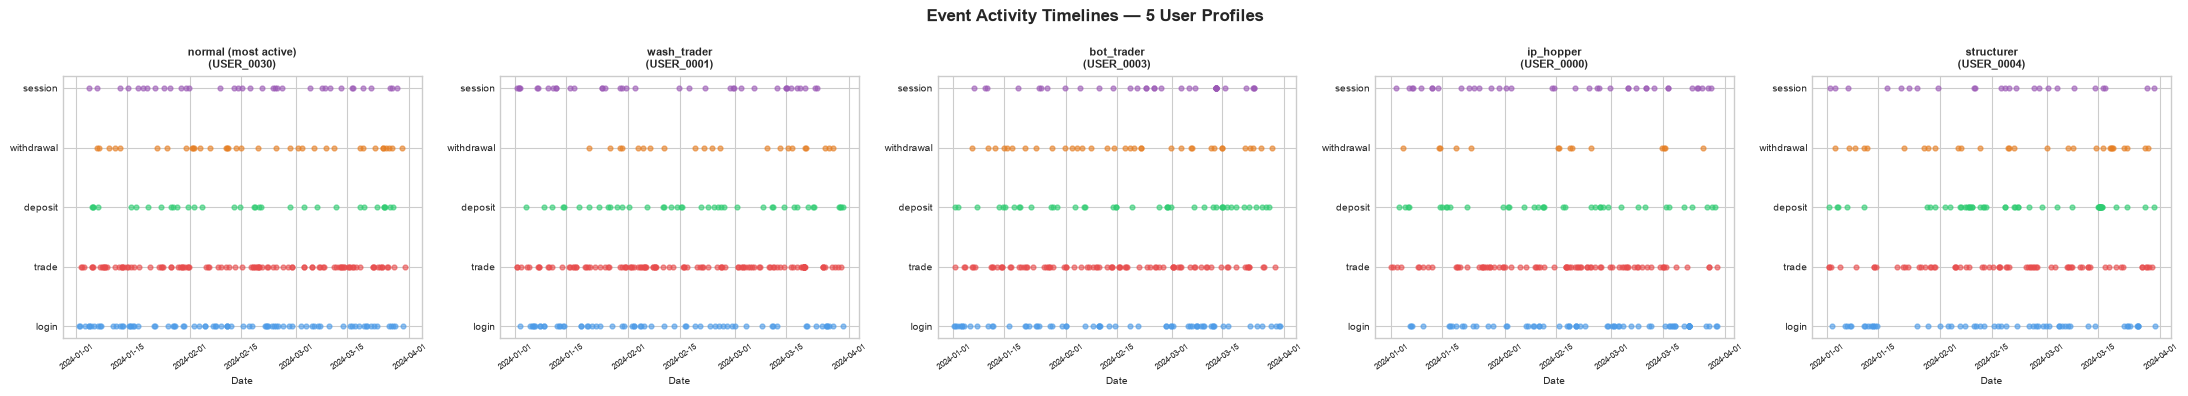

In [9]:
# Event timeline for 5 users
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
event_colors = {
    "login": "#4c9be8", "trade": "#e84c4c", "deposit": "#2ecc71",
    "withdrawal": "#e67e22", "session": "#9b59b6"
}

for i, (uid, utype) in enumerate(profile_map.items()):
    u_df = df[df["user_id"]==uid].sort_values("timestamp")
    for j, etype in enumerate(["login", "trade", "deposit", "withdrawal", "session"]):
        mask = u_df["event_type"] == etype
        axes[i].scatter(u_df[mask]["timestamp"],
                        [j] * mask.sum(),
                        s=12, alpha=0.6, color=event_colors[etype], label=etype)

    axes[i].set_title(f"{utype}\n({uid})", fontsize=8, fontweight="bold")
    axes[i].set_yticks(range(5))
    axes[i].set_yticklabels(["login","trade","deposit","withdrawal","session"], fontsize=7)
    axes[i].tick_params(axis="x", labelsize=6, rotation=35)
    axes[i].set_xlabel("Date", fontsize=7)

plt.suptitle("Event Activity Timelines — 5 User Profiles", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/user_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Observations & What's Next

Profiling these 5 users drives home a key point: **anomalous users look normal most of the time**.
The wash trader (USER_0001) has a broadly similar activity timeline to the normal user — trades,
logins, deposits — the difference is buried in 20 burst trades where the volume is 10-20× their
baseline. The structurer (USER_0004) looks almost identical to a normal depositing user unless
you zoom into the deposit amounts and find the suspicious clustering below $1,000.

**Features that look most useful going into Week 5:**
- `trade_vol_zscore` and `trade_volume_vs_baseline` — directly capture the wash trader signal
- `unique_countries_last_10_logins` — best single feature for IP hoppers
- `rolling_failed_attempts_5` — brute forcers are clear outliers
- `withdrawal_to_deposit_ratio` — deposit-withdrawal cyclers have ratios near or above 1.0
- `click_rate_per_min` (raw, not rolled) — the bot burst sessions are obvious outliers

**What I'd investigate further:**
The `session_duration_zscore` showed almost no z-scores above ±3. Session duration might be
redundant given click_rate_per_min already captures bot behavior. Worth dropping in ablation
experiments during model training.

The class imbalance (~10% anomalous events) will matter in Week 5. Isolation Forest and LOF
are designed for this scenario — they don't need balanced classes — but the anomaly score
thresholds will need careful calibration to avoid flagging too many false positives.